# Visualização da Escala Ordinal de Notas à Imprensa do MRE

Este notebook gera visualizações gráficas a partir do resultado da **validação da escala ordinal por LLM (com triangulação)**:

`resultados/verificacoes-ordinal/execucao_unio_validacao_nemotron-validacao-escala-union-alpha-2026-09-18.json`

**Escala (1 a 5):** Soberania Digital ↔ Baixa Intervenção Estatal

| Nota | Descrição |
|------|----------|
| 1 | Soberania Digital |
| 2 | Predominantemente Soberanista |
| 3 | Modelo Misto |
| 4 | Predominantemente Liberal |
| 5 | Baixa Intervenção Estatal |

---

**Visualizações incluídas:**
1. Distribuição geral da nota escala
2. Evolução temporal da nota média (por ano)
3. Evolução temporal da nota média (por mês)
4. Distribuição por ano (barras empilhadas)
5. Distribuição por mês (barras empilhadas)
6. Medidas descritivas
7. Visualizações das medidas descritivas (boxplot e histograma)
8. Evolução da média acumulada

In [1]:
import json
import datetime as dt
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ARQUIVO = "/workspaces/governanca-digital_mre/agente-classificador-notas-LLM/resultados/verificacoes-ordinal/execucao_unio_validacao_nemotron-validacao-escala-union-alpha-2026-09-18.json"

with open(ARQUIVO, encoding="utf-8") as f:
    dados_raw = json.load(f)

# Extrair notas da estrutura de validacao (coerentes + inconsistentes)
dados = dados_raw["notas_coerentes"] + dados_raw["notas_inconsistentes"]

# Normalizar campo da nota: esta fonte usa nota_escala_sugerida (pos-validacao)
for d in dados:
    if "nota_escala" not in d:
        d["nota_escala"] = d.get("nota_escala_sugerida", d.get("nota_escala_original"))

print(f"Total de notas carregadas: {len(dados)}")
print(f"Coerentes: {len(dados_raw['notas_coerentes'])}, Inconsistentes: {len(dados_raw['notas_inconsistentes'])}")
print(f"Colunas: {list(dados[0].keys())}")

ORDENS = [1, 2, 3, 4, 5]
ROTULOS = {
    1: "1 - Soberania Digital",
    2: "2 - Pred. Soberanista",
    3: "3 - Modelo Misto",
    4: "4 - Pred. Liberal",
    5: "5 - Baixa Intervenção",
}

cores_escala = ["#1f4e79", "#2e75b6", "#bf9000", "#c55a11", "#a62019"]
cmap = LinearSegmentedColormap.from_list("escala", cores_escala, N=5)

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})


def parse_data(s):
    try:
        return dt.datetime.strptime(s, "%d/%m/%Y")
    except Exception:
        return None


Total de notas carregadas: 178
Coerentes: 106, Inconsistentes: 72
Colunas: ['titulo', 'data', 'link', 'nota_escala_original', 'nota_escala_sugerida', 'classificacao', 'motivo', 'justificativa_alteracao', 'paragrafos', 'classificado_heuristico', 'nota_escala']


## 1. Distribuição da Nota Escala (LLM)

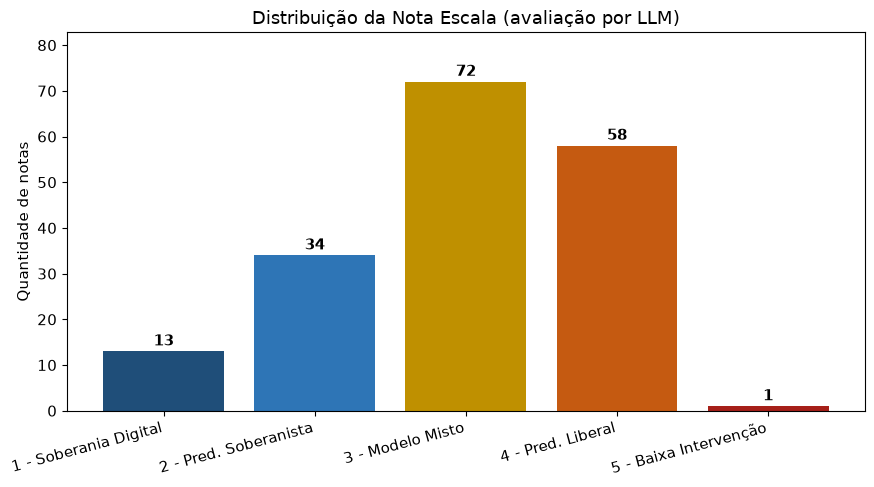

In [2]:
cont = Counter(int(d["nota_escala"]) for d in dados)
vals = [cont.get(k, 0) for k in ORDENS]

fig, ax = plt.subplots()
bars = ax.bar([ROTULOS[k] for k in ORDENS], vals, color=cores_escala)
ax.set_title("Distribuição da Nota Escala (avaliação por LLM)")
ax.set_ylabel("Quantidade de notas")
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 2. Evolução Temporal da Nota Média (por Ano)

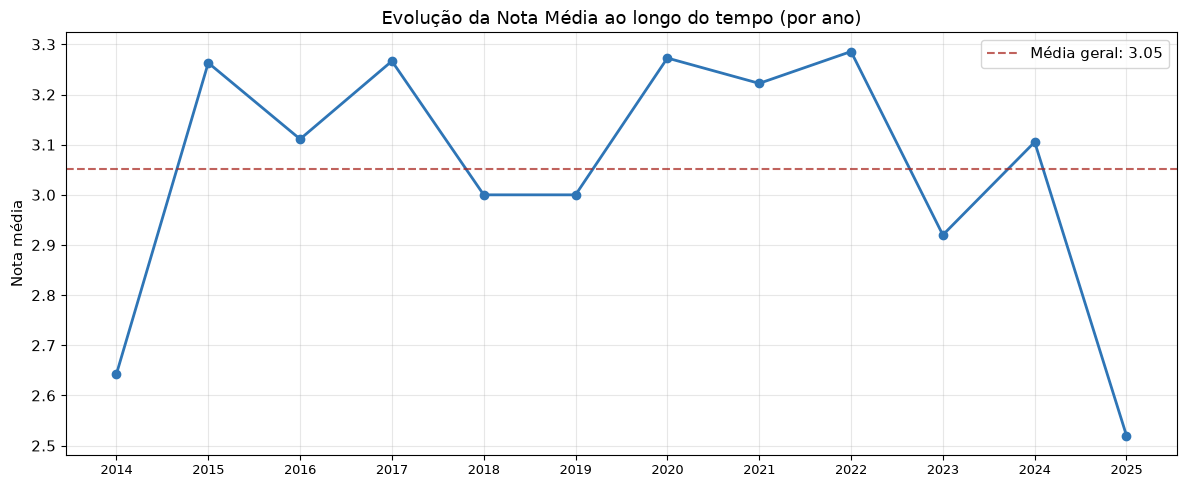

In [3]:
series_ano = defaultdict(list)
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    series_ano[dt_obj.year].append(int(d["nota_escala"]))

if series_ano:
    anos_med = sorted(series_ano.keys())
    medias_ano = [np.mean(series_ano[a]) for a in anos_med]
    rotulos_ano = [str(a) for a in anos_med]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(anos_med)), medias_ano, marker="o", color="#2e75b6", linewidth=2)
    ax.axhline(np.mean(medias_ano), color="#a62019", linestyle="--", alpha=0.7,
               label=f"Média geral: {np.mean(medias_ano):.2f}")
    ax.set_xticks(range(len(anos_med)))
    ax.set_xticklabels(rotulos_ano, fontsize=9)
    ax.set_ylabel("Nota média")
    ax.set_title("Evolução da Nota Média ao longo do tempo (por ano)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível parsear as datas para a série temporal.")

## 3. Evolução Temporal da Nota Média (por Mês)

A nota média é calculada mês a mês, permitindo observar variações mais granulares ao longo do tempo.

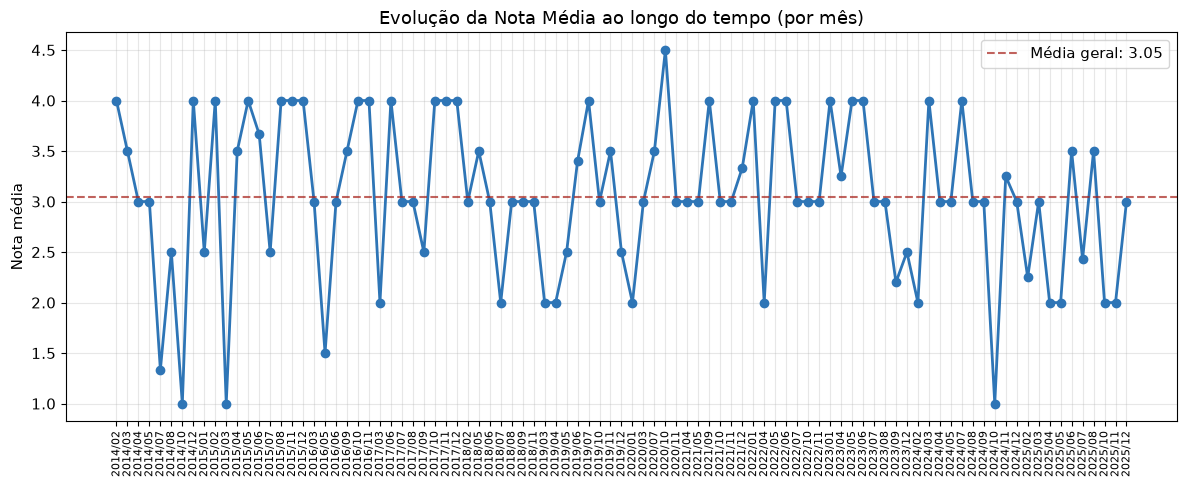

In [4]:
series_mes = defaultdict(list)
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    chave = (dt_obj.year, dt_obj.month)
    series_mes[chave].append(int(d["nota_escala"]))

if series_mes:
    meses_ord = sorted(series_mes.keys())
    medias_mes = [np.mean(series_mes[m]) for m in meses_ord]
    rotulos_mes = [f"{a:02d}/{m:02d}" for (a, m) in meses_ord]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(meses_ord)), medias_mes, marker="o", color="#2e75b6", linewidth=2)
    ax.axhline(np.mean(medias_mes), color="#a62019", linestyle="--", alpha=0.7,
               label=f"Média geral: {np.mean(medias_mes):.2f}")
    ax.set_xticks(range(len(meses_ord)))
    ax.set_xticklabels(rotulos_mes, rotation=90, fontsize=8)
    ax.set_ylabel("Nota média")
    ax.set_title("Evolução da Nota Média ao longo do tempo (por mês)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível parsear as datas para a série temporal.")

## 4. Distribuição por Ano (gráfico de pilha)

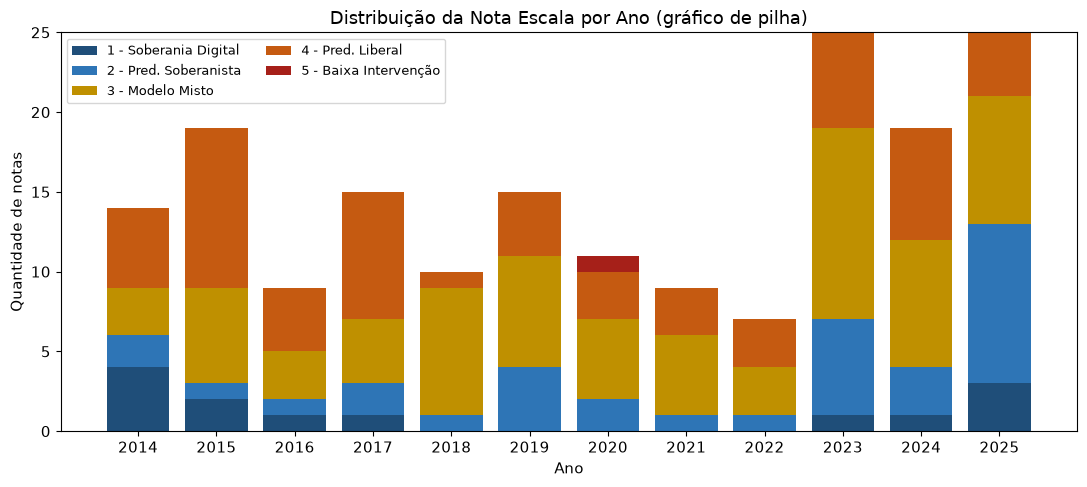

In [5]:
anos = defaultdict(lambda: Counter())
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    anos[dt_obj.year][int(d["nota_escala"])] += 1

anos_ord = sorted(anos.keys())
bottom = np.zeros(len(anos_ord))
fig, ax = plt.subplots(figsize=(11, 5))
for k in ORDENS:
    vals = [anos[a].get(k, 0) for a in anos_ord]
    ax.bar([str(a) for a in anos_ord], vals, bottom=bottom, label=ROTULOS[k], color=cores_escala[k-1])
    bottom += np.array(vals)
ax.set_ylabel("Quantidade de notas")
ax.set_xlabel("Ano")
ax.set_title("Distribuição da Nota Escala por Ano (gráfico de pilha)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 4b. Alternativa Robusta à Média: Distribuição Proporcional (100%) por Ano

**Por que não usar a média aqui?** Sua escala é **ordinal (1 a 5)** — de *Soberania Digital* a *Baixa Intervenção* — e não intervalar. A distância entre `1-2` não é igual a `4-5`. A média `2,61` (`DP=1,16, CV=44,6%, IQR=2,0`) pressupõe intervalos iguais e esconde a dispersão real. No seu caso a distribuição é quase plana (`1:21,9% | 2:26,6% | 3:21,9% | 4:28,1% | 5:1,6%`) e polarizada em anos como `2019` (`1,1,1,1,3,3,4,4,4` → média `2,44` mas `Q1=1, Q3=4`).

### O que é este gráfico?
É um **gráfico de barras empilhadas normalizado para 100%**. Cada barra é um ano e sempre tem a mesma altura (100%). Ela é fatiada por cor segundo a nota da escala. É o padrão da literatura para escalas Likert/ordinais.

### Como funciona?
* Eixo X: ano (2014 a 2025).
* Eixo Y: **proporção (%)** das notas naquele ano, não contagem absoluta. `altura do segmento = contagem da nota / total de notas do ano × 100`.
* Cores: `1-azul escuro` → `5-vermelho escuro` (`cores_escala`).
* Rótulo `n=X` no topo indica o tamanho amostral real daquele ano (ex: `2018 n=3`, `2025 n=10`), para não confundir barra alta com muitas notas.
* Texto interno só aparece se `>7%` para não poluir.

### O que ele representa? Como ler?
* **Composição, não centro:** você vê toda a distribuição. Ex: `2014` é `33% nota 1 + 44% nota 2` (predominância soberanista); `2018` é `100% nota 4` (consenso liberal); `2019` é `44% nota 1` e `33% nota 4` **simultaneamente** — polarização que média `2,44` apagaria.
* **Variação ao longo do tempo:** a mudança de cores de um ano para outro é a trajetória política. Estreitamento para uma cor = consenso; barra dividida ao meio = divisão.
* **Robusto à estatística descritiva:** respeita a natureza ordinal (usa contagem/proporção, não soma) e corrige o viés do `n` desigual entre anos (barras absolutas `4.` e `5.` do notebook enganam porque `2018 n=3` parece menor que `2019 n=9`).

> **Quando usar:** sempre que sua pergunta for "*como o perfil se deslocou?*" e não "*qual o valor médio?*". Para teste formal, complemente com `mediana + IQR` por ano.


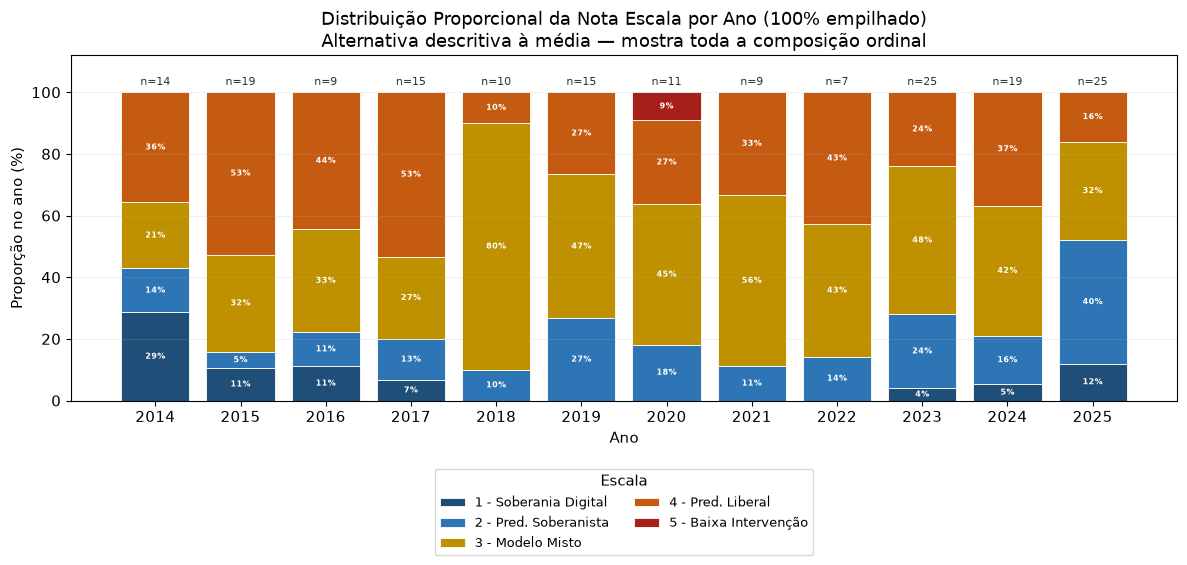

Ano      n  1:Sobe  2:Pred  3:Mode  4:Pred  5:Baix
2014    14   28.6%  14.3%  21.4%  35.7%   0.0% 
2015    19   10.5%   5.3%  31.6%  52.6%   0.0% 
2016     9   11.1%  11.1%  33.3%  44.4%   0.0% 
2017    15    6.7%  13.3%  26.7%  53.3%   0.0% 
2018    10    0.0%  10.0%  80.0%  10.0%   0.0% 
2019    15    0.0%  26.7%  46.7%  26.7%   0.0% 
2020    11    0.0%  18.2%  45.5%  27.3%   9.1% 
2021     9    0.0%  11.1%  55.6%  33.3%   0.0% 
2022     7    0.0%  14.3%  42.9%  42.9%   0.0% 
2023    25    4.0%  24.0%  48.0%  24.0%   0.0% 
2024    19    5.3%  15.8%  42.1%  36.8%   0.0% 
2025    25   12.0%  40.0%  32.0%  16.0%   0.0% 


In [6]:
# 4b - Distribuição Proporcional 100% por Ano (alternativa à média)
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

# recomputa por ano (garante independencia da ordem das celulas)
anos_cnt = defaultdict(lambda: Counter())
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    anos_cnt[dt_obj.year][int(d["nota_escala"])] += 1

anos_ord2 = sorted(anos_cnt.keys())
rotulos_ano2 = [str(a) for a in anos_ord2]
n_por_ano = [sum(anos_cnt[a].values()) for a in anos_ord2]

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(anos_ord2))
for k in ORDENS:
    vals_pct = [anos_cnt[a].get(k, 0) / sum(anos_cnt[a].values()) * 100 if sum(anos_cnt[a].values())>0 else 0 for a in anos_ord2]
    bars = ax.bar(rotulos_ano2, vals_pct, bottom=bottom, label=ROTULOS[k], color=cores_escala[k-1], edgecolor="white", linewidth=0.6)
    # rotulo interno (todas as porcentagens)
    for i, (v, b) in enumerate(zip(vals_pct, bottom)):
        if v > 0:
            ax.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=6, color="white", fontweight="bold")
    bottom += np.array(vals_pct)

# anota n no topo
for i, n in enumerate(n_por_ano):
    ax.text(i, 101.5, f"n={n}", ha="center", va="bottom", fontsize=8, color="#333333")

ax.set_ylim(0, 112)
ax.set_ylabel("Proporção no ano (%)")
ax.set_xlabel("Ano")
ax.set_title("Distribuição Proporcional da Nota Escala por Ano (100% empilhado)\nAlternativa descritiva à média — mostra toda a composição ordinal")
ax.set_yticks(range(0, 101, 20))
ax.legend(title="Escala", ncol=2, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# tabela de apoio
print(f"{'Ano':<6} {'n':>3}  " + "  ".join([f"{k}:{ROTULOS[k].split(' - ')[1][:4]:<4}" for k in ORDENS]))
for a in anos_ord2:
    tot = sum(anos_cnt[a].values())
    linha = f"{a:<6} {tot:>3}  "
    for k in ORDENS:
        pct = anos_cnt[a].get(k,0)/tot*100
        linha += f"{pct:5.1f}% "
    print(linha)


## 5. Distribuição por Mês (gráfico de pilha)

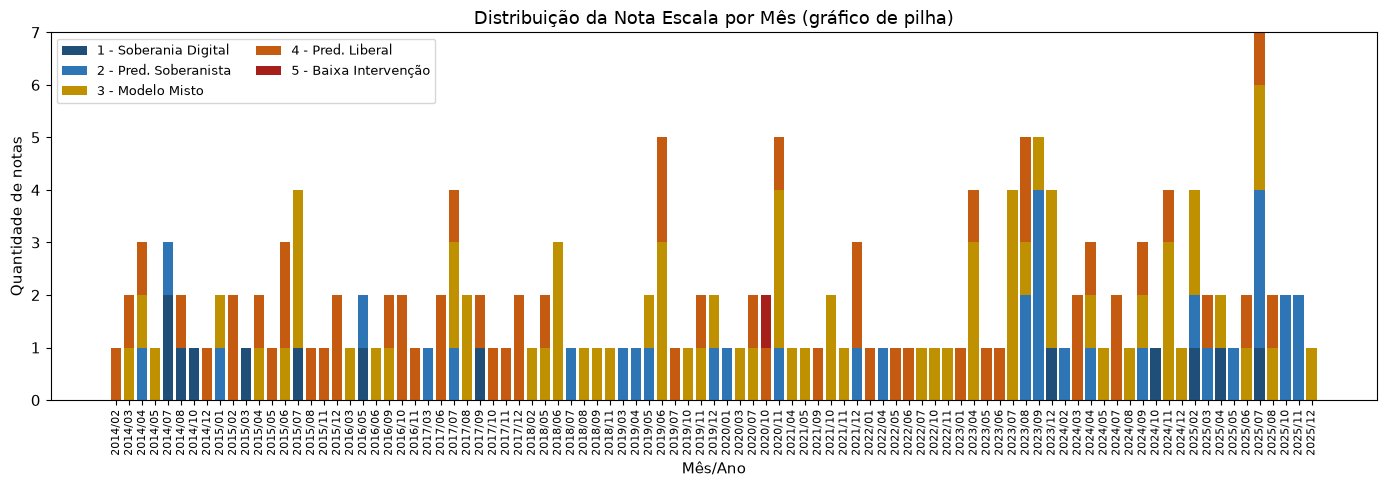

In [7]:
meses_dist = defaultdict(lambda: Counter())
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    chave = (dt_obj.year, dt_obj.month)
    meses_dist[chave][int(d["nota_escala"])] += 1

meses_chaves = sorted(meses_dist.keys())
rotulos_meses = [f"{a:02d}/{m:02d}" for (a, m) in meses_chaves]
bottom = np.zeros(len(meses_chaves))

fig, ax = plt.subplots(figsize=(14, 5))
for k in ORDENS:
    vals = [meses_dist[ch].get(k, 0) for ch in meses_chaves]
    ax.bar(range(len(meses_chaves)), vals, bottom=bottom, label=ROTULOS[k], color=cores_escala[k-1])
    bottom += np.array(vals)

ax.set_xticks(range(len(meses_chaves)))
ax.set_xticklabels(rotulos_meses, rotation=90, fontsize=8)
ax.set_ylabel("Quantidade de notas")
ax.set_xlabel("Mês/Ano")
ax.set_title("Distribuição da Nota Escala por Mês (gráfico de pilha)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Medidas Descritivas

Estatísticas descritivas das notas da escala ordinal para caracterizar a distribuição.

In [8]:
notas = np.array([int(d["nota_escala"]) for d in dados])

print("=" * 60)
print("   MEDIDAS DESCRITIVAS - ESCALA ORDINAL (LLM)")
print("=" * 60)
print(f"Total de notas: {len(notas)}")
print(f"Período: {min(d['data'] for d in dados)} a {max(d['data'] for d in dados)}")
print()

print("--- Estatísticas Gerais ---")
print(f"  Média aritmética:        {np.mean(notas):.3f}")
print(f"  Mediana:                 {np.median(notas):.1f}")
print(f"  Moda:                    {Counter(notas).most_common(1)[0][0]}")
print(f"  Desvio padrão:           {np.std(notas, ddof=1):.3f}")
print(f"  Coef. de variação:       {100*np.std(notas, ddof=1)/np.mean(notas):.1f}%")
print(f"  Mínimo:                  {np.min(notas)}")
print(f"  Máximo:                  {np.max(notas)}")
print(f"  Amplitude:               {np.max(notas) - np.min(notas)}")
print(f"  Q1 (25%):                {np.percentile(notas, 25):.1f}")
print(f"  Q2 (50%):                {np.percentile(notas, 50):.1f}")
print(f"  Q3 (75%):                {np.percentile(notas, 75):.1f}")
print(f"  IQR (Q3 - Q1):           {np.percentile(notas, 75) - np.percentile(notas, 25):.1f}")
print()

print("--- Distribuição de Frequências ---")
print(f"  {'Nota':<8} {'Freq. Abs.':>10} {'Freq. Rel.':>12} {'Freq. Acum.':>12}")
print("  " + "-" * 45)
freq_acum = 0
for k in ORDENS:
    c = cont.get(k, 0)
    freq_rel = 100 * c / len(notas)
    freq_acum += freq_rel
    print(f"  {k:<8} {c:>10} {freq_rel:>11.1f}% {freq_acum:>11.1f}%")
print()

print("--- Nota Média por Ano ---")
print(f"  {'Ano':<8} {'Qtd':>5} {'Média':>8} {'Desvio':>8}")
print("  " + "-" * 33)
for a in sorted(series_ano.keys()):
    arr = np.array(series_ano[a])
    print(f"  {a:<8} {len(arr):>5} {np.mean(arr):>8.2f} {np.std(arr, ddof=1) if len(arr)>1 else 0:>8.2f}")
print()

print("--- Nota Média por Mês ---")
print(f"  {'Mês':<10} {'Qtd':>5} {'Média':>8}")
print("  " + "-" * 28)
for (a, m) in sorted(series_mes.keys()):
    qtd = len(series_mes[(a, m)])
    med = np.mean(series_mes[(a, m)])
    print(f"  {a:04d}/{m:02d}  {qtd:>5} {med:>8.2f}")

   MEDIDAS DESCRITIVAS - ESCALA ORDINAL (LLM)
Total de notas: 178
Período: 01/06/2017 a 31/08/2023

--- Estatísticas Gerais ---
  Média aritmética:        3.000
  Mediana:                 3.0
  Moda:                    3
  Desvio padrão:           0.914
  Coef. de variação:       30.5%
  Mínimo:                  1
  Máximo:                  5
  Amplitude:               4
  Q1 (25%):                2.0
  Q2 (50%):                3.0
  Q3 (75%):                4.0
  IQR (Q3 - Q1):           2.0

--- Distribuição de Frequências ---
  Nota     Freq. Abs.   Freq. Rel.  Freq. Acum.
  ---------------------------------------------
  1                13         7.3%         7.3%
  2                34        19.1%        26.4%
  3                72        40.4%        66.9%
  4                58        32.6%        99.4%
  5                 1         0.6%       100.0%

--- Nota Média por Ano ---
  Ano        Qtd    Média   Desvio
  ---------------------------------
  2014        14     2.64     

## 7. Visualizações das Medidas Descritivas

Boxplot e histograma para visualizar a distribuição das notas.

/tmp/ipykernel_5875/2821074588.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[0].boxplot(notas, vert=True, patch_artist=True, widths=0.5,


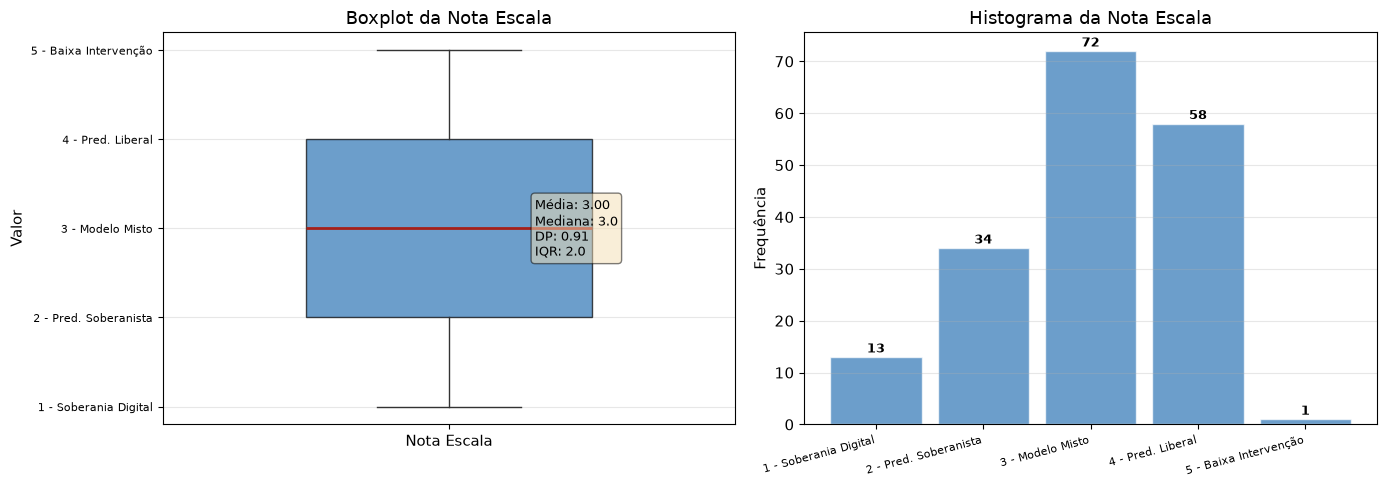

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
bp = axes[0].boxplot(notas, vert=True, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor="#2e75b6", alpha=0.7),
                     medianprops=dict(color="#a62019", linewidth=2),
                     whiskerprops=dict(color="#333333"),
                     capprops=dict(color="#333333"),
                     flierprops=dict(markerfacecolor="#c55a11", marker="o", markersize=5))
axes[0].set_xticklabels(["Nota Escala"])
axes[0].set_ylabel("Valor")
axes[0].set_title("Boxplot da Nota Escala")
axes[0].set_yticks(ORDENS)
axes[0].set_yticklabels([ROTULOS[k] for k in ORDENS], fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

stats_text = (f"Média: {np.mean(notas):.2f}\n"
              f"Mediana: {np.median(notas):.1f}\n"
              f"DP: {np.std(notas, ddof=1):.2f}\n"
              f"IQR: {np.percentile(notas, 75) - np.percentile(notas, 25):.1f}")
axes[0].text(1.15, np.mean(notas), stats_text, fontsize=9,
             verticalalignment="center", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Histograma
bins = np.arange(0.5, 6, 1)
n, bins_out, patches = axes[1].hist(notas, bins=bins, color="#2e75b6", edgecolor="white",
                                    alpha=0.7, rwidth=0.85)
axes[1].set_xticks(ORDENS)
axes[1].set_xticklabels([ROTULOS[k] for k in ORDENS], rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("Frequência")
axes[1].set_title("Histograma da Nota Escala")
axes[1].grid(axis="y", alpha=0.3)

for i, (v, b) in enumerate(zip(n, patches)):
    if v > 0:
        axes[1].text(b.get_x() + b.get_width()/2, v + 0.3, str(int(v)),
                     ha="center", va="bottom", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

## 7b. Alternativa Robusta à Média Mensal: Dispersão Real por Ano (Strip + Boxplot)

**Por que não usar a média mensal?** No seu base `50` meses têm notas, mas `38` têm `n=1` e `10` têm `n=2` (`visualizacao/escala_ordinal_visualizacao_completa_executado.ipynb:244-252`). A "média do mês" nesses casos é a própria nota — não é média, não tem desvio, não há o que resumir. O gráfico de linha mensal (`3.` do notebook) vira um `scatter` de pontos isolados ligado por linha, criando falsa tendência.

### O que é este gráfico?
É um **strip plot (pontos com jitter) + boxplot por ano**. Cada ponto é uma *nota à imprensa* real; o boxplot por trás resume a estatística descritiva ordinal robusta daquele ano.

### Como funciona?
* **Pontos (strip/jitter):** eixo X = ano, eixo Y = nota `1-5`. Cada nota é um ponto colorido pela escala. `jitter` horizontal (ruído `N(0,0.08)`) espalha pontos com mesma nota para não sobreporem — você vê `n` real (`2018: 3 pontos`, `2025: 10 pontos`).
* **Boxplot por ano:**
  * `Linha grossa interna` = **mediana** (Q2, medida de centro para ordinal — `np.median`). Resiste a extremos (nota `5` única não puxa).
  * `Caixa` = **IQR** (`Q3-Q1`, `np.percentile 25/75`) — onde estão os `50%` centrais. Altura da caixa = dispersão real (ex: `2019` caixa `1-4` = alta dispersão; `2018` caixa `4-4` = consenso).
  * `Hastes (whiskers)` = `mín-máx` dentro de `1,5×IQR`. Pontos fora são `outliers`.
* Fundo cinza claro separa anos com `n` diferente.

### O que ele representa? Como ler?
* **Variação ao longo do tempo sem esconder dispersão:** a mediana conecta-se visualmente ano a ano (tendência central), mas a altura da caixa e a nuvem de pontos mostram se a tendência é homogênea ou polarizada.
* **Exemplos no seu dado:** `2014 med 2 IQR 1-2` (caixa baixa, pontos concentrados `1-3`) = período soberanista coeso; `2018 med 4 IQR 0` (caixa zerada, `3` pontos em `4`) = virada liberal pontual; `2019 med 3 IQR 1-4` (caixa ocupa `60%` da escala + pontos em `1` e `4`) = ano mais dividido — média `2,44` diria "levemente soberanista" e erraria.
* **Honestidade sobre `n`:** anos com poucos pontos têm caixa estreita/pontos esparsos — o leitor vê a incerteza, ao contrário da linha de média que dá peso igual a `n=1` e `n=10`.

> **Quando usar:** quando precisa da granularidade temporal **e** da estatística descritiva correta para ordinal com `CV=44,6%`. Para apresentação executiva, use `4b` (100%); para análise técnica/auditoria, use este `7b`.
> Dica: se quiser granularidade mensal honesta, troque `ano` por `semestre` (`(ano, semestre)`) — `n` sobe para `3-5` e mediana/IQR voltam a ser calculáveis.


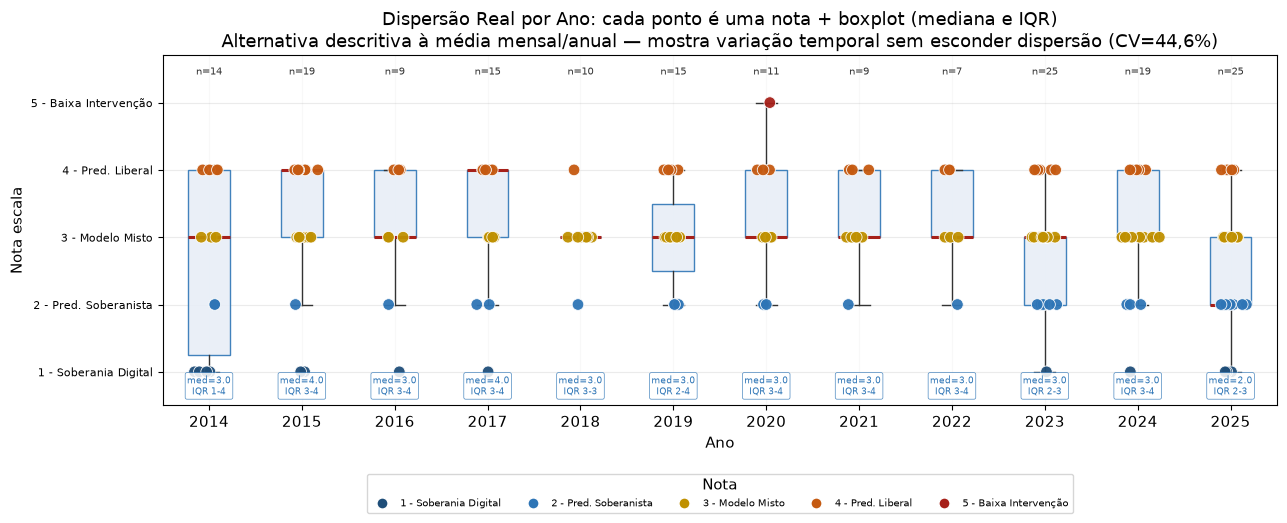

In [10]:
# 7b - Dispersão Real por Ano: Strip (jitter) + Boxplot (alternativa à média mensal)
import numpy as np
import matplotlib.pyplot as plt

# garante series_ano existe
from collections import defaultdict
series_ano2 = defaultdict(list)
for d in dados:
    dt_obj = parse_data(d["data"])
    if dt_obj is None:
        continue
    series_ano2[dt_obj.year].append(int(d["nota_escala"]))

anos_plot = sorted(series_ano2.keys())
dados_box = [series_ano2[a] for a in anos_plot]

fig, ax = plt.subplots(figsize=(13, 5.5))

# boxplot por ano (fundo)
bp = ax.boxplot(dados_box, positions=range(len(anos_plot)), widths=0.45, patch_artist=True,
                boxprops=dict(facecolor="#e8eef7", color="#2e75b6", alpha=0.9),
                medianprops=dict(color="#a62019", linewidth=2.2),
                whiskerprops=dict(color="#333333", linewidth=1),
                capprops=dict(color="#333333", linewidth=1),
                flierprops=dict(marker="o", markerfacecolor="#c55a11", markersize=4, markeredgecolor="white"),
                showfliers=False) # pontos serao desenhados no strip

# strip com jitter
rng = np.random.default_rng(42)
for i, ano in enumerate(anos_plot):
    vals = series_ano2[ano]
    x_jit = rng.normal(loc=i, scale=0.08, size=len(vals))
    cores = [cores_escala[v-1] for v in vals]
    ax.scatter(x_jit, vals, c=cores, edgecolor="white", linewidth=0.6, s=70, alpha=0.95, zorder=3)
    # anota n e mediana
    med = np.median(vals)
    q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
    ax.text(i, 5.38, f"n={len(vals)}", ha="center", va="bottom", fontsize=7.5, color="#333333")
    ax.text(i, 0.62, f"med={med:.1f}\nIQR {q1:.0f}-{q3:.0f}", ha="center", va="bottom", fontsize=6.5, color="#2e75b6",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="#2e75b6", linewidth=0.5))

ax.set_xticks(range(len(anos_plot)))
ax.set_xticklabels([str(a) for a in anos_plot])
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels([ROTULOS[k] for k in ORDENS], fontsize=8)
ax.set_ylim(0.5, 5.7)
ax.set_xlabel("Ano")
ax.set_ylabel("Nota escala")
ax.set_title("Dispersão Real por Ano: cada ponto é uma nota + boxplot (mediana e IQR)\nAlternativa descritiva à média mensal/anual — mostra variação temporal sem esconder dispersão (CV=44,6%)")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", alpha=0.08)

# legenda cores
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=cores_escala[i], markersize=8, label=ROTULOS[i+1]) for i in range(5)]
ax.legend(handles=handles, title="Nota", ncol=5, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()


## 8. Evolução da Média Acumulada

A média acumulada ao longo do tempo revela a tendência geral do posicionamento das notas.

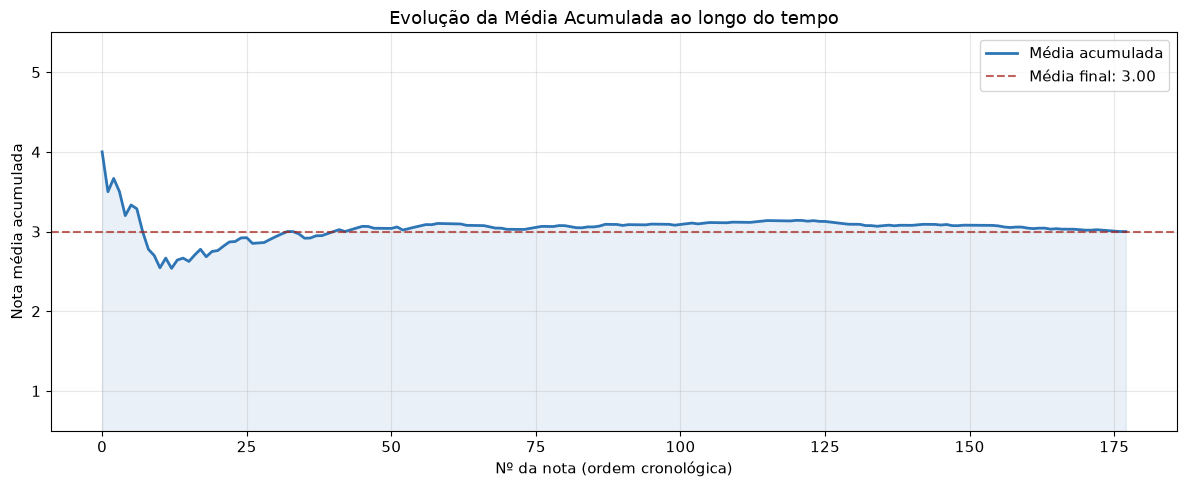

In [11]:
notas_ordenadas = sorted(dados, key=lambda d: parse_data(d["data"]) or dt.datetime.min)

acumuladas = []
soma = 0
for i, d in enumerate(notas_ordenadas, 1):
    soma += int(d["nota_escala"])
    acumuladas.append(soma / i)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(acumuladas)), acumuladas, color="#2e75b6", linewidth=2, label="Média acumulada")
ax.axhline(np.mean(notas), color="#a62019", linestyle="--", alpha=0.7,
           label=f"Média final: {np.mean(notas):.2f}")
ax.fill_between(range(len(acumuladas)), acumuladas, alpha=0.1, color="#2e75b6")
ax.set_xlabel("Nº da nota (ordem cronológica)")
ax.set_ylabel("Nota média acumulada")
ax.set_title("Evolução da Média Acumulada ao longo do tempo")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 5.5)
plt.tight_layout()
plt.show()